In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import subprocess, sys


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
import xgboost as xgb
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [17]:
# Load each Parquet file
df1 = pd.read_parquet("/home/elidrissi/mlDataset/DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet")
df2 = pd.read_parquet("/home/elidrissi/mlDataset/DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet")
df3 = pd.read_parquet("/home/elidrissi/mlDataset/DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet")
df4 = pd.read_parquet("/home/elidrissi/mlDataset/DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet")

data = pd.concat([df1, df2, df3, df4], ignore_index=True)
print(f"Total rows loaded: {len(data)}")
print(f"Columns: {data.columns.tolist()}")

Total rows loaded: 2902927
Columns: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag C

In [18]:
data = data[data['Label'] != 'DoS attacks-SlowHTTPTest']


In [19]:
data = data[data['Label'] != 'DDOS attack-LOIC-UDP']

In [20]:
print(data['Label'].value_counts())

Label
Benign                    1930404
DDoS attacks-LOIC-HTTP     575364
DDOS attack-HOIC           198861
DoS attacks-Hulk           145199
DoS attacks-GoldenEye       41406
DoS attacks-Slowloris        9908
Name: count, dtype: int64


In [22]:
# Keep only the 6 classes 
keep_labels = [
    'Benign',
    'DoS attacks-GoldenEye',
    'DoS attacks-Slowloris',
    'DoS attacks-Hulk',
    'DDoS attacks-LOIC-HTTP',
    'DDOS attack-HOIC'
]

data = data[data['Label'].isin(keep_labels)].copy()
print("\nClass counts after filtering:")
print(data['Label'].value_counts())


Class counts after filtering:
Label
Benign                    1930404
DDoS attacks-LOIC-HTTP     575364
DDOS attack-HOIC           198861
DoS attacks-Hulk           145199
DoS attacks-GoldenEye       41406
DoS attacks-Slowloris        9908
Name: count, dtype: int64


In [23]:
# Identify numeric columns (exclude 'Label')
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
zero_pct = (data[numeric_cols] == 0).mean() * 100

# Columns that are 100% zeros drop them 
cols_100_zero = zero_pct[zero_pct == 100].index.tolist()
print(f"Columns with 100% zeros: {cols_100_zero}")
data.drop(columns=cols_100_zero, inplace=True)

# Handle possible infinite values :replace with 0
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(0, inplace=True)

print(f"Remaining columns after dropping 100% zeros: {data.shape[1]}")

Columns with 100% zeros: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Remaining columns after dropping 100% zeros: 68


In [24]:
le = LabelEncoder()
data['Label_encoded'] = le.fit_transform(data['Label'])
class_names = le.classes_
print("Encoded classes:", class_names)

Encoded classes: ['Benign' 'DDOS attack-HOIC' 'DDoS attacks-LOIC-HTTP'
 'DoS attacks-GoldenEye' 'DoS attacks-Hulk' 'DoS attacks-Slowloris']


In [25]:
# Separate features and target
X = data.drop(columns=['Label', 'Label_encoded'])
y = data['Label_encoded']

# Split 
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set size: {len(X_train_full)}")
print(f"Test set size: {len(X_test)}")

Training set size: 2320913
Test set size: 580229


In [26]:
print(data['Label'].unique())

dos_ddos_labels = [
    'Benign',
    'DoS attacks-GoldenEye',
    'DoS attacks-Slowloris',
    'DoS attacks-Hulk',
 
    'DDOS attack-HOIC'   ]    

df = data[data['Label'].isin(dos_ddos_labels )]
print(df['Label'].value_counts())

<ArrowStringArray>
[                'Benign',  'DoS attacks-GoldenEye',  'DoS attacks-Slowloris',
       'DoS attacks-Hulk', 'DDoS attacks-LOIC-HTTP',       'DDOS attack-HOIC']
Length: 6, dtype: str
Label
Benign                   1930404
DDOS attack-HOIC          198861
DoS attacks-Hulk          145199
DoS attacks-GoldenEye      41406
DoS attacks-Slowloris       9908
Name: count, dtype: int64


In [30]:


#---------------------------------------------------------
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

# DOWNSAMPLING (cap majority classes)
MAX_SAMPLES = {
    0: 100000,   # Benign       → cap (was 1.5M)
    1:  80000,   # HOIC         → cap (was 159K)
    2: 100000,   # LOIC-HTTP    → cap (was 460K)
    3:  33125,   # GoldenEye    → keep all
    4:  80000,   # Hulk         → cap (was 116K)
    5:   7926,   # Slowloris    → keep all (smallest)
}

train_df = X_train_full.copy()
train_df['Label_encoded'] = y_train_full

balanced_parts = []
for label, max_n in MAX_SAMPLES.items():
    class_df = train_df[train_df['Label_encoded'] == label]
    n = min(len(class_df), max_n)
    balanced_parts.append(
        resample(class_df,
                 replace=False,
                 n_samples=n,
                 random_state=RANDOM_STATE)
    )

balanced_df = pd.concat(balanced_parts)\
                .sample(frac=1, random_state=RANDOM_STATE)\
                .reset_index(drop=True)

X_train = balanced_df.drop(columns=['Label_encoded'])
y_train  = balanced_df['Label_encoded']

print("AFTER DOWNSAMPLING")
print(y_train.value_counts().sort_index())
print(f"\nTotal training samples : {len(y_train):,}")
print(f"Imbalance ratio        : "
      f"{y_train.value_counts().max() / y_train.value_counts().min():.1f}x")




# UPWEIGHTING (give more importance to rare classes)

# Option A — Automatic balanced weights (simple)from sklearn.preprocessing import label_binarize
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
def get_custom_weights(y, class_weights_dict):
    weights = np.ones(len(y), dtype=float)
    for class_idx, weight in class_weights_dict.items():
        weights[y == class_idx] = weight
    return weights

sample_weights= get_custom_weights(y_train, custom_class_weights)

print("\n" + "=" * 45)
print("UPWEIGHTING SUMMARY")
print("=" * 45)
for class_idx, weight in custom_class_weights.items():
    count = (y_train == class_idx).sum()
    effective = count * weight
    print(f"Class {class_idx} ({le.classes_[class_idx]:<25})"
          f" count: {count:>7,}  weight: {weight:>4.1f}x  "
          f"effective: {effective:>10,.0f}")


#  TRAIN WITH BOTH
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    early_stopping_rounds=30,
    random_state=RANDOM_STATE
)

# Split a validation set
X_train_sub, X_val, y_train_sub, y_val, w_train, w_val = train_test_split(
    X_train, y_train, sample_weights,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

xgb_model.fit(
    X_train_sub, y_train_sub,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print("\n Model trained with downsampling + upweighting!")
#---------------------------------------------------------

AFTER DOWNSAMPLING
Label_encoded
0    100000
1     80000
2    100000
3     33125
4     80000
5      7926
Name: count, dtype: int64

Total training samples : 401,051
Imbalance ratio        : 12.6x

UPWEIGHTING SUMMARY
Class 0 (Benign                   ) count: 100,000  weight:  1.0x  effective:    100,000
Class 1 (DDOS attack-HOIC         ) count:  80,000  weight:  1.5x  effective:    120,000
Class 2 (DDoS attacks-LOIC-HTTP   ) count: 100,000  weight:  1.0x  effective:    100,000
Class 3 (DoS attacks-GoldenEye    ) count:  33,125  weight:  3.0x  effective:     99,375
Class 4 (DoS attacks-Hulk         ) count:  80,000  weight:  1.5x  effective:    120,000
Class 5 (DoS attacks-Slowloris    ) count:   7,926  weight:  8.0x  effective:     63,408
[0]	validation_0-mlogloss:1.59654
[50]	validation_0-mlogloss:0.10882
[100]	validation_0-mlogloss:0.01011
[150]	validation_0-mlogloss:0.00135
[200]	validation_0-mlogloss:0.00048
[250]	validation_0-mlogloss:0.00037
[300]	validation_0-mlogloss:0.00035


In [31]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit sur train uniquement
X_test_scaled  = scaler.transform(X_test)         # 



full_feature_columns = X_train.columns.tolist()  
selector = SelectKBest(mutual_info_classif, k=k_features)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected  = selector.transform(X_test_scaled)

selected_features = X_train.columns[selector.get_support()].tolist()
print(f"Selected {len(selected_features)} features")

X_train = pd.DataFrame(X_train_selected, columns=selected_features)
X_test  = pd.DataFrame(X_test_selected,  columns=selected_features)

Selected 60 features


In [32]:
X_train_sub, X_val, y_train_sub, y_val, \
sample_weights_sub, sample_weights_val = train_test_split(
    X_train, y_train, sample_weights,   
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f"X_train_sub : {X_train_sub.shape}")
print(f"X_val       : {X_val.shape}")

X_train_sub : (320840, 60)
X_val       : (80211, 60)


In [34]:

# Subset custom_weights_B for train and validation
custom_weights_B_sub = custom_weights_B[y_train.index.isin(X_train_sub.index)]
custom_weights_B_val = custom_weights_B[y_train.index.isin(X_val.index)]





xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    tree_method='hist',
    device='cuda',                     
    eval_metric='mlogloss',
    early_stopping_rounds=30,          
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train with early stopping – eval_set goes in fit()
xgb_model.fit(
    X_train_sub, y_train_sub,
    sample_weight=custom_weights_B_sub,          
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[custom_weights_B_val], 
    verbose=50
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

[0]	validation_0-mlogloss:1.33978
[50]	validation_0-mlogloss:0.01011
[100]	validation_0-mlogloss:0.00047
[150]	validation_0-mlogloss:0.00029
[200]	validation_0-mlogloss:0.00028
[238]	validation_0-mlogloss:0.00028

Best iteration: 208


In [35]:
# Add this after training:
y_pred_train = xgb_model.predict(X_train_sub)
y_pred_test  = xgb_model.predict(X_test)

train_f1 = f1_score(y_train_sub, y_pred_train, average='weighted')
test_f1  = f1_score(y_test,      y_pred_test,  average='weighted')

print(f"Train F1 : {train_f1:.4f}")
print(f"Test  F1 : {test_f1:.4f}")
print(f"Gap      : {abs(train_f1 - test_f1):.4f}  {'OK' if abs(train_f1-test_f1) < 0.01 else 'Overfitting!'}")

Train F1 : 1.0000
Test  F1 : 0.9999
Gap      : 0.0001  ✅ OK


In [36]:
#  Code corrigé — optimisation globale sur F1 weighted
from sklearn.calibration import CalibratedClassifierCV

def find_optimal_thresholds(model, X_val, y_val, le):

    y_proba = model.predict_proba(X_val)
    n_classes = len(le.classes_)
    thresholds = {i: 0.5 for i in range(n_classes)}

    print("=" * 50)
    print("OPTIMIZING PER-CLASS THRESHOLDS (global F1)")
    print("=" * 50)

    best_global_f1 = 0.0
    best_thresholds = thresholds.copy()


    for benign_thresh in np.arange(0.30, 0.95, 0.05):
        candidate = {i: 0.5 for i in range(n_classes)}
        candidate[0] = benign_thresh  

        y_pred_custom = []
        for probs in y_proba:
            passed = {i: probs[i] for i in range(n_classes) if probs[i] >= candidate[i]}
            if passed:
                pred = max(passed, key=passed.get)
            else:
                pred = int(np.argmax(probs))
            y_pred_custom.append(pred)

        f1 = f1_score(y_val, y_pred_custom, average='weighted', zero_division=0)
        if f1 > best_global_f1:
            best_global_f1 = f1
            best_thresholds = candidate.copy()

    for idx, name in enumerate(le.classes_):
        print(f"  Class {idx} ({name}): threshold = {best_thresholds[idx]:.2f}")
    print(f"  Best global F1 (weighted): {best_global_f1:.4f}")
    print("=" * 50)
    return best_thresholds

In [37]:
optimal_thresholds = find_optimal_thresholds(xgb_model, X_val, y_val, le)

OPTIMIZING PER-CLASS THRESHOLDS (global F1)
  Class 0 (Benign): threshold = 0.30
  Class 1 (DDOS attack-HOIC): threshold = 0.50
  Class 2 (DDoS attacks-LOIC-HTTP): threshold = 0.50
  Class 3 (DoS attacks-GoldenEye): threshold = 0.50
  Class 4 (DoS attacks-Hulk): threshold = 0.50
  Class 5 (DoS attacks-Slowloris): threshold = 0.50
  → Best global F1 (weighted): 0.9999


FINAL EVALUATION (80/20 random stratified split)
Accuracy  : 0.9999
F1 (weighted) : 0.9999
Precision (weighted): 0.9999
Recall (weighted)   : 0.9999

Classification Report:
                        precision    recall  f1-score   support

                Benign       1.00      1.00      1.00    386081
      DDOS attack-HOIC       1.00      1.00      1.00     39772
DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
 DoS attacks-GoldenEye       1.00      1.00      1.00      8281
      DoS attacks-Hulk       1.00      1.00      1.00     29040
 DoS attacks-Slowloris       0.99      1.00      0.99      1982

              accuracy                           1.00    580229
             macro avg       1.00      1.00      1.00    580229
          weighted avg       1.00      1.00      1.00    580229



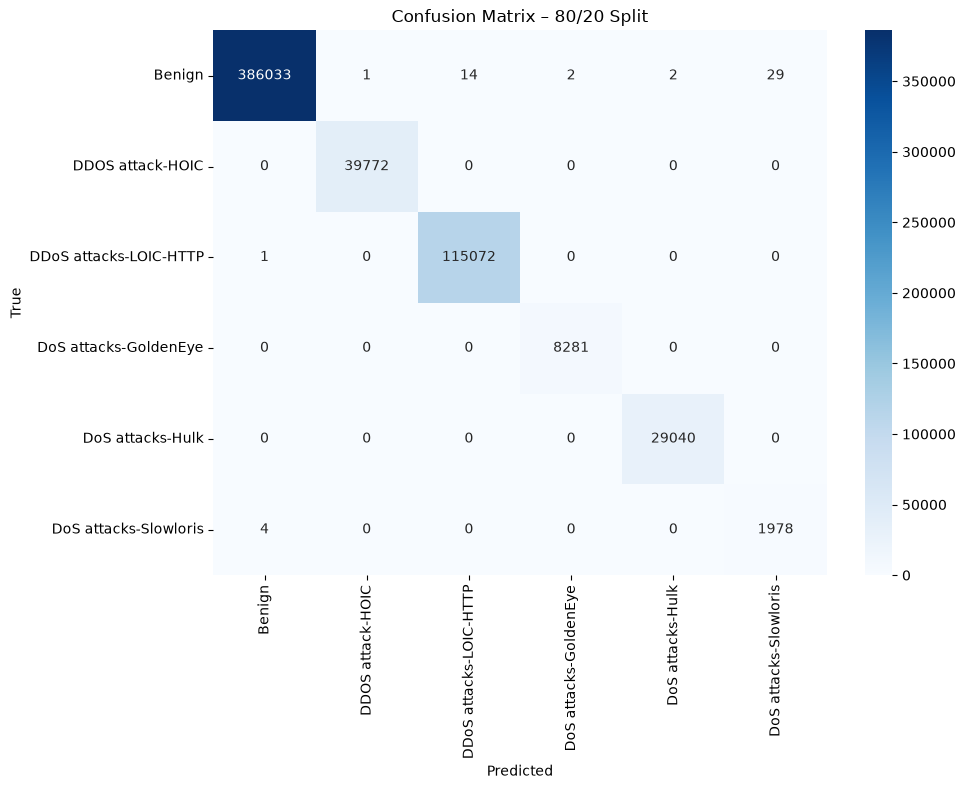

In [38]:
def predict_with_thresholds(model, X, thresholds, n_classes):
    y_proba = model.predict_proba(X)
    y_pred = []
    for probs in y_proba:
        passed = {i: probs[i] for i in range(n_classes) if probs[i] >= thresholds[i]}
        pred = max(passed, key=passed.get) if passed else int(np.argmax(probs))
        y_pred.append(pred)
    return np.array(y_pred)

y_pred = predict_with_thresholds(xgb_model, X_test, optimal_thresholds, len(le.classes_))
y_pred_proba = xgb_model.predict_proba(X_test)

# Overall metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("FINAL EVALUATION (80/20 random stratified split)")
print(f"Accuracy  : {accuracy:.4f}")
print(f"F1 (weighted) : {f1_weighted:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted)   : {recall:.4f}")

# Per-class report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – 80/20 Split')
plt.tight_layout()
plt.show()

In [39]:
# Binarize the labels for one-vs-rest
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities
y_score = xgb_model.predict_proba(X_test)

# Compute AUC for each class
auc_per_class = {}
for i in range(n_classes):
    auc_per_class[le.classes_[i]] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
weighted_auc = roc_auc_score(y_test_bin, y_score, average='weighted', multi_class='ovr')

print("\n" + "="*60)
print("ROC‑AUC PER CLASS")
print("="*60)
for cls, auc_val in auc_per_class.items():
    print(f"  {cls:<28} : {auc_val:.6f}")



ROC‑AUC PER CLASS
  Benign                       : 1.000000
  DDOS attack-HOIC             : 1.000000
  DDoS attacks-LOIC-HTTP       : 1.000000
  DoS attacks-GoldenEye        : 1.000000
  DoS attacks-Hulk             : 1.000000
  DoS attacks-Slowloris        : 1.000000

Macro AUC    : 1.000000
Weighted AUC : 1.000000


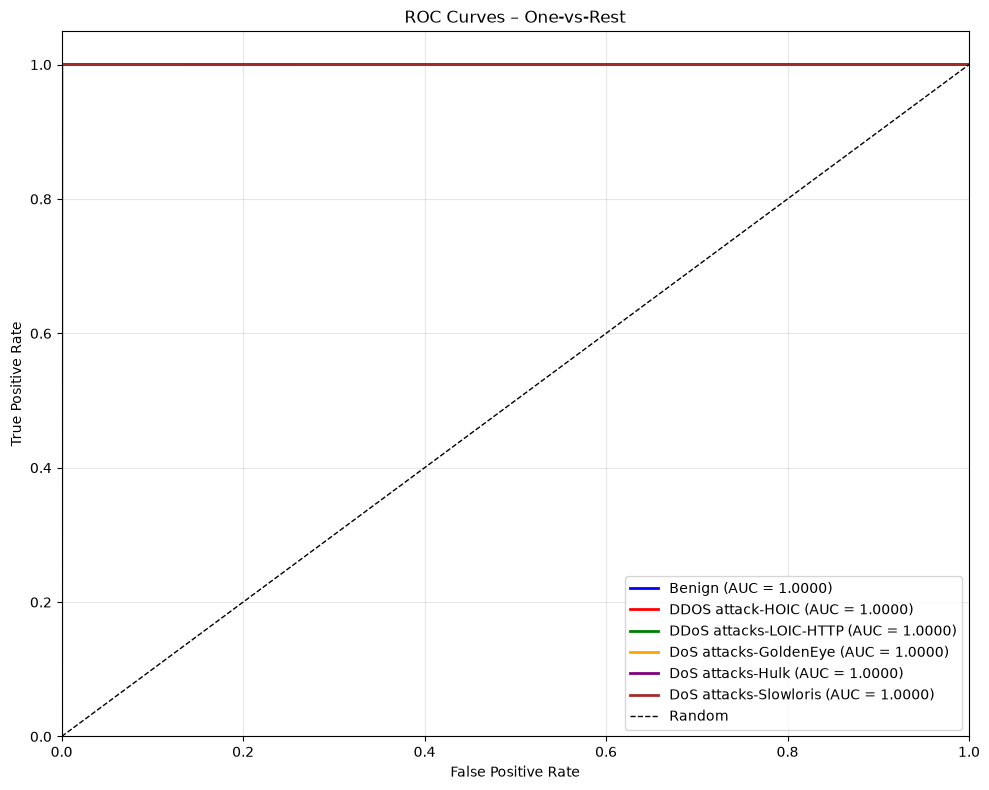

In [40]:
# Compute ROC curves for each class
fpr = {}
tpr = {}
thresh = {}
for i in range(n_classes):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test_bin[:, i], y_score[:, i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
for i, color in enumerate(colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{le.classes_[i]} (AUC = {auc_per_class[le.classes_[i]]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – One-vs-Rest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# ================================================================
# CELL 32.5: LOAD 2017 CSV & DEFINE ALIAS MAPPING
# ================================================================

import pandas as pd
import numpy as np

# 1. Load the 2017 CSV dataset (adjust the path to your file)
csv_path = '/home/elidrissi/mlDataset/Wednesday-workingHours.pcap_ISCX.csv'
df_2017 = pd.read_csv(csv_path)

# Strip leading/trailing whitespace from all column names
df_2017.columns = df_2017.columns.str.strip()
print(f"{len(df_2017)} rows. Columns: {len(df_2017.columns)}")

# 2. Define the normalisation helper
def normalize_string(text):
    """Remove non-alphanumeric characters and lowercase."""
    return "".join(c for c in str(text).lower() if c.isalnum())

# 3. Build the comprehensive alias dictionary (2018 → 2017 column name mapping)
def build_alias_dictionary():
    full_map = {
        'flowduration'              : ['flowduration'],
        'totalfwdpackets'           : ['totalfwdpackets'],
        'totalbackwardpackets'      : ['totalbackwardpackets'],

        'fwdpacketslengthtotal'     : ['totallengthoffwdpackets'],
        'bwdpacketslengthtotal'     : ['totallengthofbwdpackets'],

        'fwdpacketlengthmax'        : ['fwdpacketlengthmax'],
        'fwdpacketlengthmin'        : ['fwdpacketlengthmin'],
        'fwdpacketlengthmean'       : ['fwdpacketlengthmean'],
        'fwdpacketlengthstd'        : ['fwdpacketlengthstd'],
        'bwdpacketlengthmax'        : ['bwdpacketlengthmax'],
        'bwdpacketlengthmin'        : ['bwdpacketlengthmin'],
        'bwdpacketlengthmean'       : ['bwdpacketlengthmean'],
        'bwdpacketlengthstd'        : ['bwdpacketlengthstd'],
        'flowbytess'                : ['flowbytess'],
        'flowpacketss'              : ['flowpacketss'],
        'flowiatmean'               : ['flowiatmean'],
        'flowiatstd'                : ['flowiatstd'],
        'flowiatmax'                : ['flowiatmax'],
        'flowiatmin'                : ['flowiatmin'],
        'fwdiattotal'               : ['fwdiattotal'],
        'fwdiatmean'                : ['fwdiatmean'],
        'fwdiatstd'                 : ['fwdiatstd'],
        'fwdiatmax'                 : ['fwdiatmax'],
        'fwdiatmin'                 : ['fwdiatmin'],
        'bwdiattotal'               : ['bwdiattotal'],
        'bwdiatmean'                : ['bwdiatmean'],
        'bwdiatstd'                 : ['bwdiatstd'],
        'bwdiatmax'                 : ['bwdiatmax'],
        'bwdiatmin'                 : ['bwdiatmin'],
        'fwdpshflags'               : ['fwdpshflags'],
        'fwdheaderlength'           : ['fwdheaderlength'],
        'bwdheaderlength'           : ['bwdheaderlength'],
        'fwdpacketss'               : ['fwdpacketss'],
        'bwdpacketss'               : ['bwdpacketss'],
        'packetlengthmin'           : ['minpacketlength'],
        'packetlengthmax'           : ['maxpacketlength'],
        'packetlengthmean'          : ['packetlengthmean'],
        'packetlengthstd'           : ['packetlengthstd'],
        'packetlengthvariance'      : ['packetlengthvariance'],
        'finflagcount'              : ['finflagcount'],
        'synflagcount'              : ['synflagcount'],
        'rstflagcount'              : ['rstflagcount'],
        'pshflagcount'              : ['pshflagcount'],
        'ackflagcount'              : ['ackflagcount'],
        'urgflagcount'              : ['urgflagcount'],
        'eceflagcount'              : ['eceflagcount'],
        'downupratio'               : ['downupratio'],
        'avgpacketsize'             : ['averagepacketsize'],
        'avgfwdsegmentsize'         : ['avgfwdsegmentsize'],
        'avgbwdsegmentsize'         : ['avgbwdsegmentsize'],
        'subflowfwdpackets'         : ['subflowfwdpackets'],
        'subflowfwdbytes'           : ['subflowfwdbytes'],
        'subflowbwdpackets'         : ['subflowbwdpackets'],
        'subflowbwdbytes'           : ['subflowbwdbytes'],
        'initfwdwinbytes'           : ['initwinbytesforward'],
        'initbwdwinbytes'           : ['initwinbytesbackward'],
        'fwdactdatapackets'         : ['actdatapktfwd'],
        'fwdsegsizemin'             : ['minsegsizeforward'],
        'activemean'                : ['activemean'],
        'activestd'                 : ['activestd'],
        'activemax'                 : ['activemax'],
        'activemin'                 : ['activemin'],
        'idlemean'                  : ['idlemean'],
        'idlestd'                   : ['idlestd'],
        'idlemax'                   : ['idlemax'],
        'idlemin'                   : ['idlemin'],
        # Protocol not in 2017 will default to 0
    }
    return full_map

alias_dict = build_alias_dictionary()
print("✅ Alias dictionary built. Ready for inference.")

📦 Loading /home/elidrissi/mlDataset/Wednesday-workingHours.pcap_ISCX.csv ...
✅ Loaded 692703 rows. Columns: 79
✅ Alias dictionary built. Ready for inference.


In [25]:
label_mapping_2017 = {
    'BENIGN'          : 'Benign',
    'DoS Hulk'        : 'DoS attacks-Hulk',
    'DoS slowloris'   : 'DoS attacks-Slowloris',
    'DoS GoldenEye'   : 'DoS attacks-GoldenEye',
    'DoS Slowhttptest': 'DoS attacks-SlowHTTPTest',
    'Heartbleed'      : None  #  skip thia one (not in 2018)
}

df_2017_test = df_2017[df_2017['Label'].isin(label_mapping_2017.keys())].copy()
df_2017_test = df_2017_test[df_2017_test['Label'] != 'Heartbleed']  
df_2017_test['Label'] = df_2017_test['Label'].map(label_mapping_2017)

print(f"2017 test rows: {len(df_2017_test)}")
print(df_2017_test['Label'].value_counts())

2017 test rows: 692692
Label
Benign                      440031
DoS attacks-Hulk            231073
DoS attacks-GoldenEye        10293
DoS attacks-Slowloris         5796
DoS attacks-SlowHTTPTest      5499
Name: count, dtype: int64


In [27]:
def predict_blind_csv_row_custom(model, df_csv, full_feature_columns, 
                                  thresholds, le, scaler, selector):
    # Input validation
    while True:
        try:
            user_input = input(f"\n Enter a 2017 row index (0 to {len(df_csv)-1}): ")
            row_idx = int(user_input)
            if 0 <= row_idx < len(df_csv):
                break
            else:
                print("Out of range")
        except ValueError:
            print("Invalid input")

    # Extract and align row
    raw_row = df_csv.iloc[row_idx].to_dict()
    norm_2017 = {}
    for col, val in raw_row.items():
        base = col.split('.')[0]
        norm_2017[normalize_string(base)] = val

    aligned_sample = {}
    for model_col in full_feature_columns:
        norm_model = normalize_string(model_col)
        if norm_model in norm_2017:
            aligned_sample[model_col] = norm_2017[norm_model]
        elif norm_model in alias_dict:
            matched = False
            for alias in alias_dict[norm_model]:
                if alias in norm_2017:
                    aligned_sample[model_col] = norm_2017[alias]
                    matched = True
                    break
            if not matched:
                aligned_sample[model_col] = 0.0
        else:
            aligned_sample[model_col] = 0.0

    
    for col in aligned_sample:
        try:
            val = float(aligned_sample[col])
            aligned_sample[col] = 0.0 if (np.isnan(val) or np.isinf(val)) else val
        except:
            aligned_sample[col] = 0.0

    
    input_raw = pd.DataFrame([aligned_sample])[full_feature_columns]

    # Step 1 — Apply the SAME scaler used during training
    input_scaled = pd.DataFrame(
        scaler.transform(input_raw),
        columns=full_feature_columns
    )

    # Step 2 — Apply the SAME feature selector used during training
    input_selected = pd.DataFrame(
        selector.transform(input_scaled),
        columns=selected_features
    )

    # Predict
    pred_probs = model.predict_proba(input_selected)[0]

    # Apply thresholds
    best_class = 0
    best_score = 0.0
    for class_idx, thresh in thresholds.items():
        prob = pred_probs[class_idx]
        if prob >= thresh and prob > best_score:
            best_score = prob
            best_class = class_idx

    confidence = pred_probs[best_class] * 100

    # Print report
    print("PREDICTION (2017 DATA — FIXED PIPELINE)")
    print(f" 🔹 Row Index     : {row_idx}")
    print(f" 🔹 Decision      : {le.classes_[best_class]} (encoded: {best_class})")
    print(f" 🔹 Confidence    : {confidence:.2f}%")
    print("="*50)
    if best_class == 0:
        print("STATUS: TRAFFIC SEEMS CLEAR / SAFE")
    else:
        print("STATUS: MALICIOUS ACTIVITY FLAGGED!")
    print("Probability Distribution:")
    for idx, name in enumerate(le.classes_):
        thresh = thresholds.get(idx, 0.5)
        passed = "✅" if pred_probs[idx] >= thresh else "⬜"
        print(f"   • {str(name):<26}: {pred_probs[idx]*100:>6.2f}%  "
              f"(threshold: {thresh:.2f}) {passed}")
    print("="*50 + "\n")


predict_blind_csv_row_custom(
    xgb_model, df_2017, full_feature_columns,
    simple_thresholds, le,
    scaler,    
    selector  
)


🔹 Enter a 2017 row index (0 to 692702):  81951



🛡️  PREDICTION (2017 DATA — FIXED PIPELINE)
 🔹 Row Index     : 81951
 🔹 Decision      : Benign (encoded: 0)
 🔹 Confidence    : 99.64%
 🟩 STATUS: TRAFFIC SEEMS CLEAR / SAFE
--------------------------------------------------
 📊 Probability Distribution:
   • Benign                    :  99.64%  (threshold: 0.95) ✅
   • DDOS attack-HOIC          :   0.00%  (threshold: 0.25) ⬜
   • DDoS attacks-LOIC-HTTP    :   0.00%  (threshold: 0.30) ⬜
   • DoS attacks-GoldenEye     :   0.16%  (threshold: 0.40) ⬜
   • DoS attacks-Hulk          :   0.20%  (threshold: 0.10) ⬜
   • DoS attacks-Slowloris     :   0.00%  (threshold: 0.10) ⬜



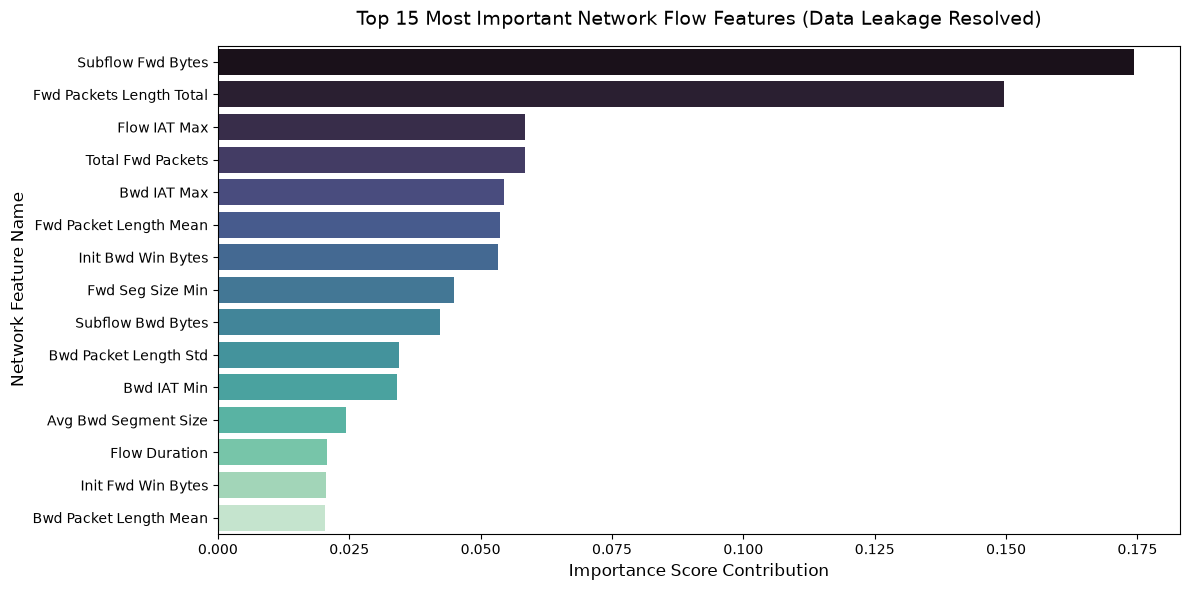

✅ Cell 7 Complete.


In [28]:
# Top 15 Most Important Network Features
importances = xgb_model.feature_importances_
feature_names = X_train.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=rf_importances.head(15).values, 
    y=rf_importances.head(15).index, 
    palette="mako", 
    hue=rf_importances.head(15).index, 
    legend=False
)
plt.title("Top 15 Most Important Network Flow Features (Data Leakage Resolved)", fontsize=14, pad=15)
plt.xlabel("Importance Score Contribution", fontsize=12)
plt.ylabel("Network Feature Name", fontsize=12)
plt.tight_layout()
plt.show()



In [ ]:

joblib.dump(xgb_model, 'xgb_model_v3.pkl')
joblib.dump(le, 'label_encoder_v3.pkl')
joblib.dump(selected_features, 'selected_features_v3.pkl')
print("Model, encoder, and selected features saved.")